In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful")

All imports successful


# Customer Segmentation Analysis
## UCI Online Retail Dataset

This notebook covers:
- Data loading and cleaning
- Exploratory Data Analysis (EDA) using Python + SQL (DuckDB)
- RFM (Recency, Frequency, Monetary) Analysis
- Customer Segmentation via K-Means Clustering

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Plotting config
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

# Paths
DATA_PATH = "../data/raw/Online Retail.xlsx"

print("Config set")

Config set


In [3]:
print("Loading dataset... (may take 20–30 seconds for xlsx)")
df = pd.read_excel(DATA_PATH, engine="openpyxl")
print(f"Shape: {df.shape}")
df.head()

Loading dataset... (may take 20–30 seconds for xlsx)
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step 1: Data Cleaning

In [4]:
print("=== Basic Info ===")
print(f"Shape: {df.shape}")
print(f"\n=== Null Values ===")
print(df.isnull().sum())
print(f"\n=== Data Types ===")
print(df.dtypes)
print(f"\n=== Duplicates ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== Basic Info ===
Shape: (541909, 8)

=== Null Values ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== Data Types ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

=== Duplicates ===
Duplicate rows: 5268


In [5]:
# Drop rows with missing CustomerID (can't segment without it)
df_clean = df.dropna(subset=["CustomerID"])

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove cancellations (InvoiceNo starting with 'C')
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]

# Remove rows where Quantity or UnitPrice <= 0
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Fix data types
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int).astype(str)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Add revenue column
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Focus on UK only
df_uk = df_clean[df_clean["Country"] == "United Kingdom"].copy()

print(f"Original shape:  {df.shape}")
print(f"Cleaned shape:   {df_clean.shape}")
print(f"UK-only shape:   {df_uk.shape}")
print(f"\nDate range: {df_uk['InvoiceDate'].min()} → {df_uk['InvoiceDate'].max()}")

Original shape:  (541909, 8)
Cleaned shape:   (392692, 9)
UK-only shape:   (349203, 9)

Date range: 2010-12-01 08:26:00 → 2011-12-09 12:49:00


## Step 2: Exploratory Data Analysis (EDA)
### Using DuckDB for SQL-based analysis

In [6]:
# Register the cleaned UK dataframe as a SQL table
con = duckdb.connect()
con.register("transactions", df_uk)

print("DuckDB connection ready")
print("Table 'transactions' registered")

DuckDB connection ready
Table 'transactions' registered


In [8]:
## Run a basic SQL query to get an overview of the cleaned dataset
con.execute("""
    SELECT
        COUNT(*)                                    AS total_rows,
        COUNT(DISTINCT CustomerID)                  AS unique_customers,
        COUNT(DISTINCT InvoiceNo)                   AS unique_invoices,
        COUNT(DISTINCT StockCode)                   AS unique_products,
        ROUND(SUM(Revenue), 2)                      AS total_revenue,
        ROUND(AVG(Revenue), 2)                      AS avg_revenue_per_row,
        MIN(InvoiceDate)                            AS first_transaction,
        MAX(InvoiceDate)                            AS last_transaction
    FROM transactions
""").df()

,total_rows,unique_customers,unique_invoices,unique_products,total_revenue,avg_revenue_per_row,first_transaction,last_transaction
0,349203,3920,16646,3645,7285024.64,20.86,2010-12-01 08:26:00,2011-12-09 12:49:00


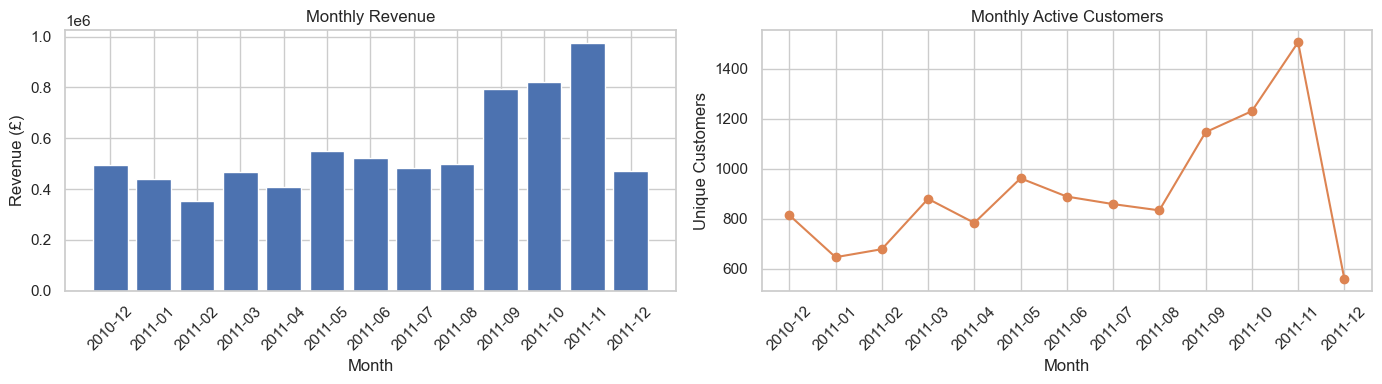

,month,monthly_revenue,active_customers,num_orders
0,2010-12,496477.34,815,1291
1,2011-01,440876.33,647,874
2,2011-02,354618.20,679,896
3,2011-03,465784.19,880,1177
4,2011-04,408733.11,784,1058
5,2011-05,550359.35,962,1403
6,2011-06,523775.59,889,1249
7,2011-07,484545.59,859,1200
8,2011-08,497194.91,834,1133
9,2011-09,794806.69,1146,1568


In [9]:
## Analyze monthly revenue and active customers over time
monthly = con.execute("""
    SELECT
        STRFTIME(InvoiceDate, '%Y-%m')      AS month,
        ROUND(SUM(Revenue), 2)              AS monthly_revenue,
        COUNT(DISTINCT CustomerID)          AS active_customers,
        COUNT(DISTINCT InvoiceNo)           AS num_orders
    FROM transactions
    GROUP BY month
    ORDER BY month
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(monthly["month"], monthly["monthly_revenue"], color="#4C72B0")
axes[0].set_title("Monthly Revenue")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue (£)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(monthly["month"], monthly["active_customers"], marker="o", color="#DD8452")
axes[1].set_title("Monthly Active Customers")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Unique Customers")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
monthly

In [10]:
## Top 10 products by revenue
con.execute("""
    SELECT
        StockCode,
        Description,
        COUNT(DISTINCT InvoiceNo)       AS times_ordered,
        SUM(Quantity)                   AS total_qty_sold,
        ROUND(SUM(Revenue), 2)          AS total_revenue
    FROM transactions
    GROUP BY StockCode, Description
    ORDER BY total_revenue DESC
    LIMIT 10
""").df()

,StockCode,Description,times_ordered,total_qty_sold,total_revenue
0,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995.0,168469.60
1,22423,REGENCY CAKESTAND 3 TIER,1410,9617.0,110713.00
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1884,34630.0,94805.50
3,23166,MEDIUM CERAMIC TOP STORAGE JAR,173,76919.0,80291.44
4,85099B,JUMBO BAG RED RETROSPOT,1447,41878.0,77191.33
5,47566,PARTY BUNTING,1290,13980.0,63050.28
6,84879,ASSORTED COLOUR BIRD ORNAMENT,1300,32628.0,52228.68
7,79321,CHILLI LIGHTS,508,9494.0,45483.91
8,22086,PAPER CHAIN KIT 50'S CHRISTMAS,945,14772.0,40392.08
9,22502,PICNIC BASKET WICKER 60 PIECES,2,61.0,39619.50


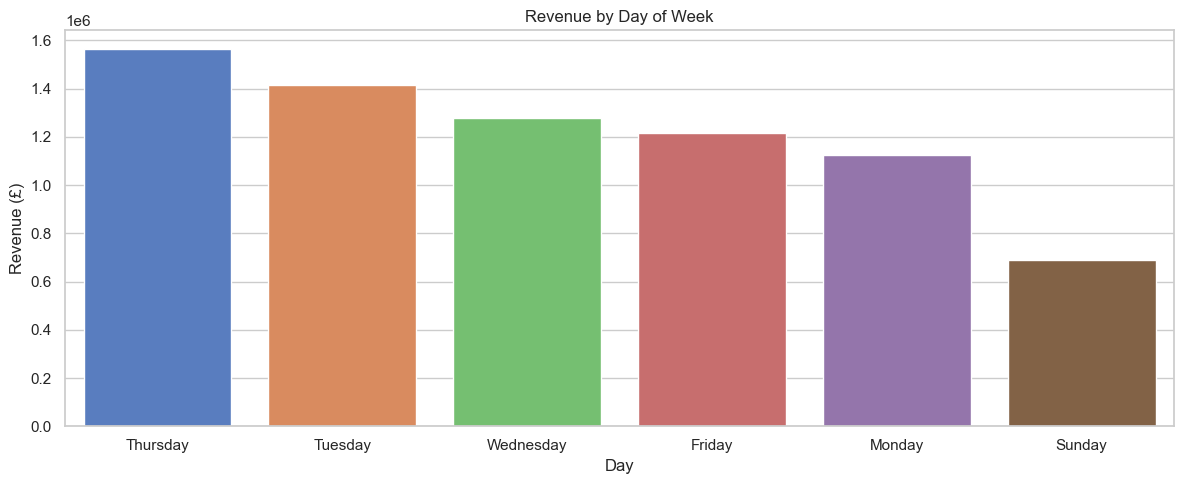

,day_of_week,total_revenue,num_orders
0,Thursday,1563033.23,3599
1,Tuesday,1415788.97,2887
2,Wednesday,1276826.58,3091
3,Friday,1215510.03,2478
4,Monday,1126022.15,2553
5,Sunday,687843.68,2038


In [11]:
## Revenue by day of week
dow = con.execute("""
    SELECT
        DAYNAME(InvoiceDate)            AS day_of_week,
        ROUND(SUM(Revenue), 2)          AS total_revenue,
        COUNT(DISTINCT InvoiceNo)       AS num_orders
    FROM transactions
    GROUP BY day_of_week
    ORDER BY total_revenue DESC
""").df()

sns.barplot(data=dow, x="day_of_week", y="total_revenue", palette="muted")
plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()
dow

## Step 3: RFM Analysis
RFM measures customer value across three dimensions:
- **Recency** — how recently did they purchase?
- **Frequency** — how many times did they purchase?
- **Monetary** — how much did they spend in total?

In [12]:
#  Build RFM table with DuckDB
# Snapshot date = 1 day after last transaction
snapshot_date = df_uk["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

con.execute(f"SET VARIABLE snapshot = '{snapshot_date}'")

rfm = con.execute("""
    SELECT
        CustomerID,
        DATEDIFF('day',
            MAX(InvoiceDate),
            CAST(getvariable('snapshot') AS TIMESTAMP))   AS recency,
        COUNT(DISTINCT InvoiceNo)                          AS frequency,
        ROUND(SUM(Revenue), 2)                             AS monetary
    FROM transactions
    GROUP BY CustomerID
    ORDER BY monetary DESC
""").df()

print(f"RFM table shape: {rfm.shape}")
rfm.head(10)

Snapshot date: 2011-12-10 12:49:00
RFM table shape: (3920, 4)


,CustomerID,recency,frequency,monetary
0,18102,1,60,259657.30
1,17450,9,46,194390.79
2,16446,1,2,168472.50
3,17511,3,31,91062.38
4,16029,39,63,80850.84
5,12346,326,1,77183.60
6,16684,5,28,66653.56
7,14096,5,17,65164.79
8,13694,4,50,65039.62
9,15311,1,91,60632.75


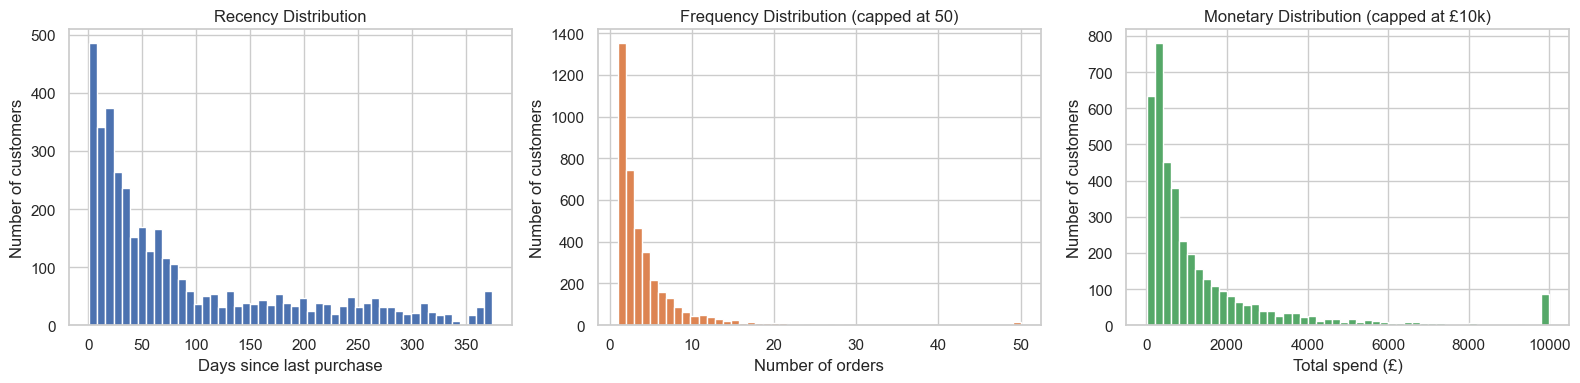

In [13]:
# RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm["recency"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last purchase")
axes[0].set_ylabel("Number of customers")

axes[1].hist(rfm["frequency"].clip(upper=50), bins=50, color="#DD8452", edgecolor="white")
axes[1].set_title("Frequency Distribution (capped at 50)")
axes[1].set_xlabel("Number of orders")
axes[1].set_ylabel("Number of customers")

axes[2].hist(rfm["monetary"].clip(upper=10000), bins=50, color="#55A868", edgecolor="white")
axes[2].set_title("Monetary Distribution (capped at £10k)")
axes[2].set_xlabel("Total spend (£)")
axes[2].set_ylabel("Number of customers")

plt.tight_layout()
plt.show()

In [14]:
# RFM scoring with SQL
rfm_scored = con.execute("""
    WITH percentiles AS (
        SELECT
            CustomerID, recency, frequency, monetary,
            NTILE(5) OVER (ORDER BY recency DESC)    AS r_score,
            NTILE(5) OVER (ORDER BY frequency ASC)   AS f_score,
            NTILE(5) OVER (ORDER BY monetary ASC)    AS m_score
        FROM rfm
    )
    SELECT *,
        CONCAT(CAST(r_score AS VARCHAR),
               CAST(f_score AS VARCHAR),
               CAST(m_score AS VARCHAR))             AS rfm_segment,
        ROUND((r_score + f_score + m_score) / 3.0, 2) AS rfm_score
    FROM percentiles
    ORDER BY rfm_score DESC
""").df()

print(rfm_scored.shape)
rfm_scored.head(10)

(3920, 9)


,CustomerID,recency,frequency,monetary,r_score,f_score,m_score,rfm_segment,rfm_score
0,13784,10,11,2462.79,5,5,5,555,5.0
1,15750,3,8,2463.05,5,5,5,555,5.0
2,14766,9,6,2473.37,5,5,5,555,5.0
3,17188,12,7,2474.23,5,5,5,555,5.0
4,17682,11,6,2474.33,5,5,5,555,5.0
5,15271,8,15,2493.34,5,5,5,555,5.0
6,15932,5,8,2495.87,5,5,5,555,5.0
7,17449,3,7,2519.21,5,5,5,555,5.0
8,13394,2,8,2520.02,5,5,5,555,5.0
9,14701,11,9,2526.09,5,5,5,555,5.0


In [15]:
# Assign segment labels
def label_segment(row):
    score = row["rfm_score"]
    r = row["r_score"]
    f = row["f_score"]
    if score >= 4.5:
        return "Champions"
    elif score >= 3.5:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "Promising"
    elif r >= 3 and score >= 3.0:
        return "Potential Loyalists"
    elif r <= 2 and score >= 3.0:
        return "At Risk"
    elif r <= 2 and score < 2.5:
        return "Lost"
    else:
        return "Need Attention"

rfm_scored["segment"] = rfm_scored.apply(label_segment, axis=1)

# Summary by segment
segment_summary = rfm_scored.groupby("segment").agg(
    num_customers=("CustomerID", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean")
).round(2).sort_values("num_customers", ascending=False)

print(segment_summary)

                     num_customers  avg_recency  avg_frequency  avg_monetary
segment                                                                     
Lost                          1078       218.55           1.25        374.86
Loyal Customers                819        36.70           5.16       2169.46
Champions                      577        10.46          13.92       7150.82
Need Attention                 522        82.46           1.64        463.93
Promising                      369        18.56           1.43        397.28
Potential Loyalists            320        38.93           2.67        700.47
At Risk                        235       125.56           3.42       1554.01


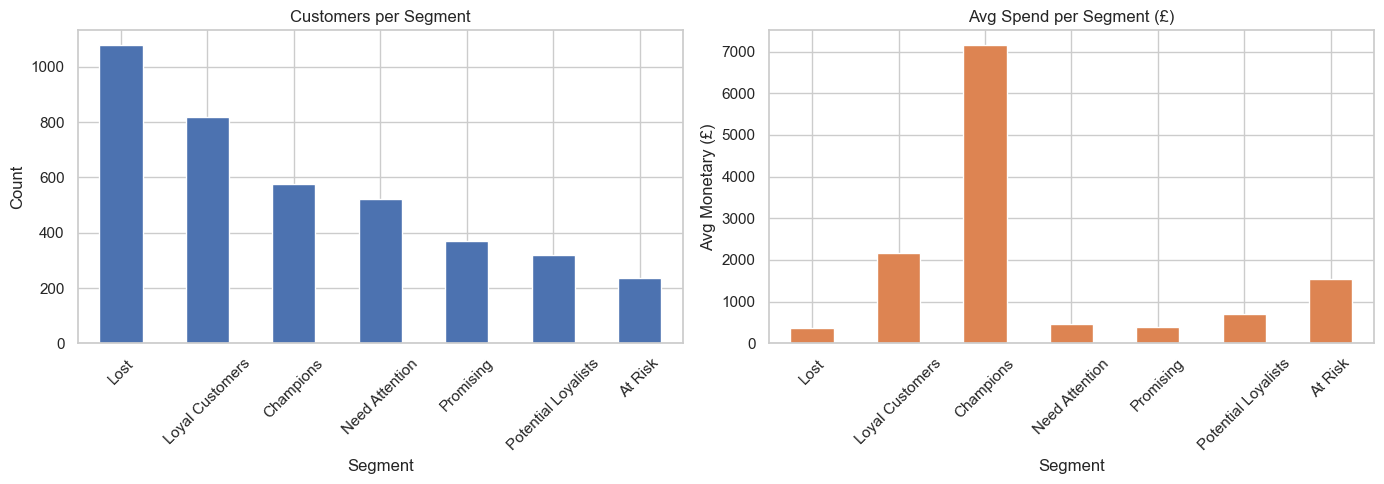

In [16]:
# Segment visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer count per segment
segment_summary["num_customers"].plot(
    kind="bar", ax=axes[0], color="#4C72B0", edgecolor="white"
)
axes[0].set_title("Customers per Segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Avg monetary per segment
segment_summary["avg_monetary"].plot(
    kind="bar", ax=axes[1], color="#DD8452", edgecolor="white"
)
axes[1].set_title("Avg Spend per Segment (£)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Avg Monetary (£)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Step 4: Save Processed Data

In [17]:
import os

os.makedirs("../data/processed", exist_ok=True)

# Save cleaned transactions
df_uk.to_csv("../data/processed/transactions_clean.csv", index=False)

# Save RFM scored table
rfm_scored.to_csv("../data/processed/rfm_scored.csv", index=False)

print("Saved:")
print(f"  ../data/processed/transactions_clean.csv  — {df_uk.shape}")
print(f"  ../data/processed/rfm_scored.csv          — {rfm_scored.shape}")

Saved:
  ../data/processed/transactions_clean.csv  — (349203, 9)
  ../data/processed/rfm_scored.csv          — (3920, 10)


## Summary

| Metric | Value |
|---|---|
| Total UK transactions | 349,203 |
| Unique customers | 3,920 |
| Total revenue | £7,285,024 |
| Date range | Dec 2010 – Dec 2011 |
| Segments identified | 7 |

**Key findings:**
- Revenue peaks in Nov 2011 — clear holiday seasonality
- Thursday is the highest revenue day
- Champions (577 customers) drive disproportionate revenue at £7,150 avg spend
- 1,078 customers are Lost — re-engagement opportunity
- 235 At Risk customers averaged £1,554 — worth saving before they churn